In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score






import requests

import io

query = """
SELECT pl_orbper, pl_bmasse, pl_insol, pl_rade, st_teff, st_logg, st_rad, st_mass, sy_vmag
FROM pscomppars
"""
url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
r = requests.get(url, params={"query": query, "format": "csv"})
df = pd.read_csv(io.StringIO(r.text))


In [226]:
df = df.dropna(subset=[
    "pl_insol", "pl_rade"
])

In [227]:
print(f"Vorher: {len(df)} Zeilen")
df = df.dropna(subset=["pl_insol", "pl_rade"])
print(f"Nachher: {len(df)} Zeilen")

Vorher: 5715 Zeilen
Nachher: 5715 Zeilen


#X und Y festlegen

In [228]:

df["habitable"] = (
    (df["pl_insol"].between(0.25, 1.5)) &
    (df["pl_rade"].between(0.5, 1.6))
).astype(int)




# 3. Erst danach X und y daraus bauen
X = df[["pl_orbper", "pl_bmasse", "st_teff", "st_logg", "st_rad", "st_mass", "sy_vmag"]]
y = df["habitable"]


habitable
0    5683
1      32
Name: count, dtype: int64
Anteil bewohnbar: 0.0056
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1705
           1       0.71      0.50      0.59        10

    accuracy                           1.00      1715
   macro avg       0.86      0.75      0.79      1715
weighted avg       1.00      1.00      1.00      1715



In [230]:
print(y.value_counts(normalize=True))


habitable
0    0.994401
1    0.005599
Name: proportion, dtype: float64


In [231]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [232]:
# Ersetze [92] durch:
model = make_pipeline(
    SimpleImputer(strategy="median"),  # Füllt NaNs sauber erst beim fit()
    StandardScaler(),
    RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42
))
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pl_orbper','pl_bmasse','st_teff',...,'st_rad','st_mass','sy_vmag']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string

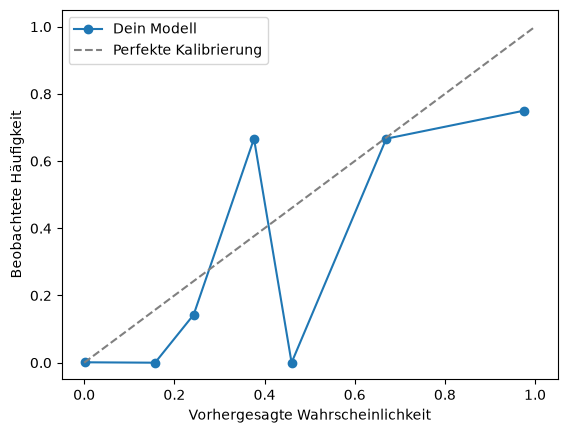

In [233]:
from sklearn.calibration import calibration_curve

y_proba = model.predict_proba(X_test)[:, 1]
frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.plot(mean_pred, frac_pos, marker="o", label="Dein Modell")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfekte Kalibrierung")
plt.xlabel("Vorhergesagte Wahrscheinlichkeit")
plt.ylabel("Beobachtete Häufigkeit")
plt.legend()
plt.show()

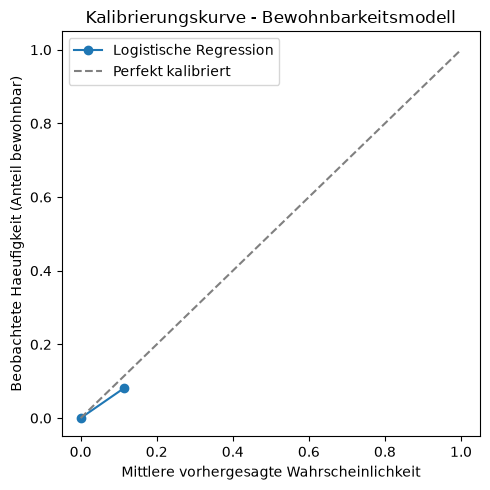

In [234]:
from sklearn.calibration import calibration_curve

# Vorhergesagte Wahrscheinlichkeiten fuer die positive Klasse (bewohnbar)
y_prob = model.predict_proba(X_test)[:, 1]

# n_bins ggf. anpassen, je nach Anzahl Testbeispiele in der Minderheitsklasse
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(prob_pred, prob_true, marker="o", label="Logistische Regression")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfekt kalibriert")
ax.set_xlabel("Mittlere vorhergesagte Wahrscheinlichkeit")
ax.set_ylabel("Beobachtete Haeufigkeit (Anteil bewohnbar)")
ax.set_title("Kalibrierungskurve - Bewohnbarkeitsmodell")
ax.legend()
plt.tight_layout()
plt.show()

habitable
0    5683
1      32
Name: count, dtype: int64
Anteil bewohnbar: 0.0056
Min/Max/Mean der Vorhersagen: 0.0 1.0 0.008180758017492712


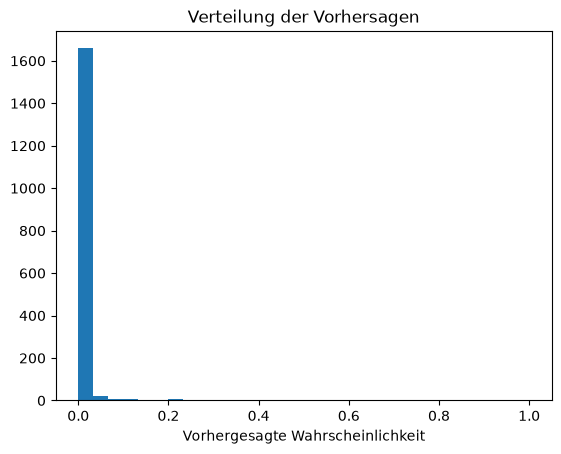

Positive im Trainingsset: 22
Positive im Testset: 10
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1705
           1       0.71      0.50      0.59        10

    accuracy                           1.00      1715
   macro avg       0.86      0.75      0.79      1715
weighted avg       1.00      1.00      1.00      1715



In [ ]:

print(df["habitable"].value_counts())
print(f"Anteil bewohnbar: {y.mean():.4f}")

# Wie sehen die vorhergesagten Wahrscheinlichkeiten aus?
y_proba = model.predict_proba(X_test)[:, 1]
print("Min/Max/Mean der Vorhersagen:", y_proba.min(), y_proba.max(), y_proba.mean())
plt.hist(y_proba, bins=30)
plt.xlabel("Vorhergesagte Wahrscheinlichkeit")
plt.title("Verteilung der Vorhersagen")
plt.show()

# Wie viele positive Fälle landen überhaupt im Testset?
print("Positive im Trainingsset:", y_train.sum())
print("Positive im Testset:", y_test.sum())

# Klassischer Bericht
print(classification_report(y_test, model.predict(X_test)))